In [ ]:
from pathlib import Path
import os

_cwd = Path.cwd().resolve()
if (_cwd / "Mar2_2026_Data").is_dir():
    PL_ROOT = _cwd
elif (_cwd.parent / "Mar2_2026_Data").is_dir():
    PL_ROOT = _cwd.parent
else:
    raise RuntimeError(
        "Run Jupyter with cwd = Physician_Labels, or open this notebook from Physician_Labels/notebooks."
    )
os.chdir(PL_ROOT)

In [1]:
import pandas as pd

# Load the data
output_path = "results/14B_Physician_Comparison_with_Stats.csv"
QWEN14B = pd.read_csv(output_path)


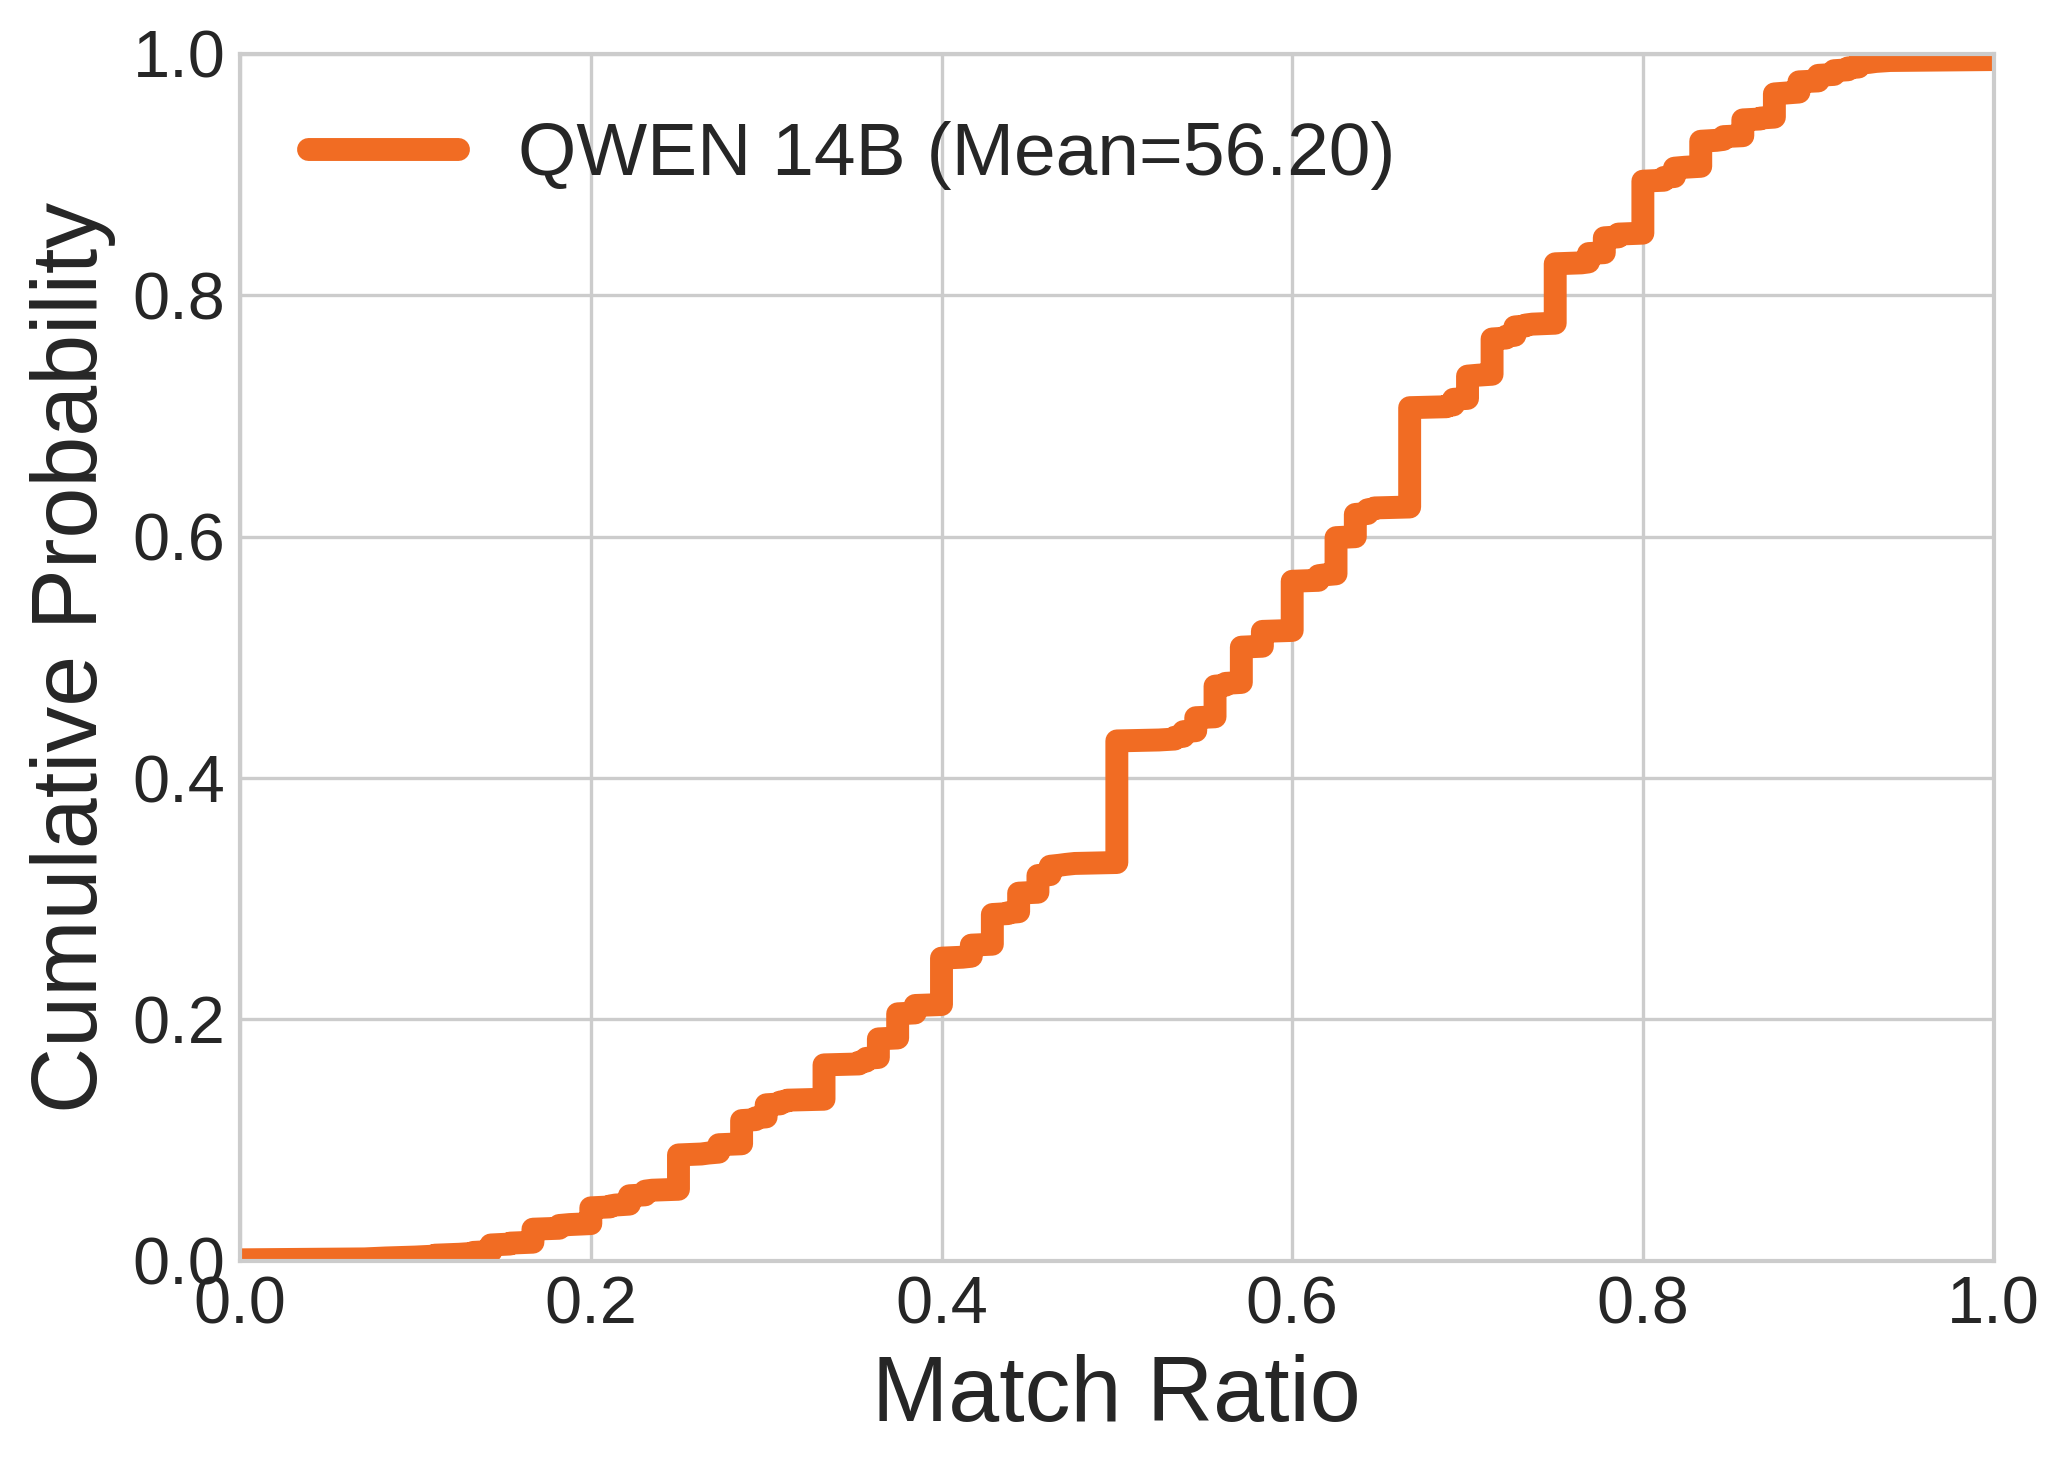

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the data
output_path = "results/14B_Physician_Comparison_with_Stats.csv"
QWEN14B = pd.read_csv(output_path)

# === Convert "Match?" column to numeric ratios ===
def parse_match(value):
    if pd.isna(value):
        return np.nan
    if value == 1:
        return 1.0
    if isinstance(value, str) and "/" in value:
        num, denom = value.split("/")
        try:
            return float(num) / float(denom)
        except:
            return np.nan
    return np.nan

# Compute numeric match ratios for physician
QWEN14B["Match_Ratio"] = (
    QWEN14B["match_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
    .div(100)
    .round(3)
)
ratios_QWEN14B = QWEN14B["Match_Ratio"].dropna().values

# === Compute sorted values for CDF ===
def cdf_data(data):
    data_sorted = np.sort(data)
    yvals = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
    return data_sorted, yvals

x_phys, y_phys = cdf_data(ratios_QWEN14B)

# === Compute mean and 95% CI ===
def mean_ci(data):
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    n = len(data)
    margin = 1.96 * std / np.sqrt(n)
    return mean, (mean - margin, mean + margin)

mean_phys, ci_phys = mean_ci(ratios_phys)

# === Plot setup ===
plt.figure(figsize=(7,5), dpi=300)
plt.style.use("seaborn-v0_8-whitegrid")

color_QWEN14B = "#f16c23"   # Physician blue

# Plot the CDF
plt.plot(x_phys, y_phys, color=color_QWEN14B, linewidth=5.5,
         label=f"QWEN 14B (Mean={mean_phys:.2f})")

# # Shaded 95% CI region
# plt.fill_betweenx([0, 1], ci_phys[0], ci_phys[1],
#                   color=color_phys, alpha=0.12)

# # Dashed mean line
# plt.axvline(mean_phys, color=color_phys, linestyle='--',
#             linewidth=1.8, alpha=0.9)

# Axis labels, title, and limits
plt.xlabel("Match Ratio", fontsize=22)
plt.ylabel("Cumulative Probability", fontsize=22)
# plt.title("Cumulative Distribution of Physician Label Concordance",
#           fontsize=15, weight="bold")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.legend(frameon=False, fontsize=18)
plt.tight_layout()

# Save high-resolution version
plt.savefig("cdf_14B_only.png", dpi=600, bbox_inches="tight")
plt.show()
